# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
from scipy import stats

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
- $r^2$은 이 관계에서 무엇을 의미하나요?
- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?



[Pearson 상관분석]
상관계수 r : 0.709
p-value : 0.000 | 판단 : 유의하다.
r² : 0.502


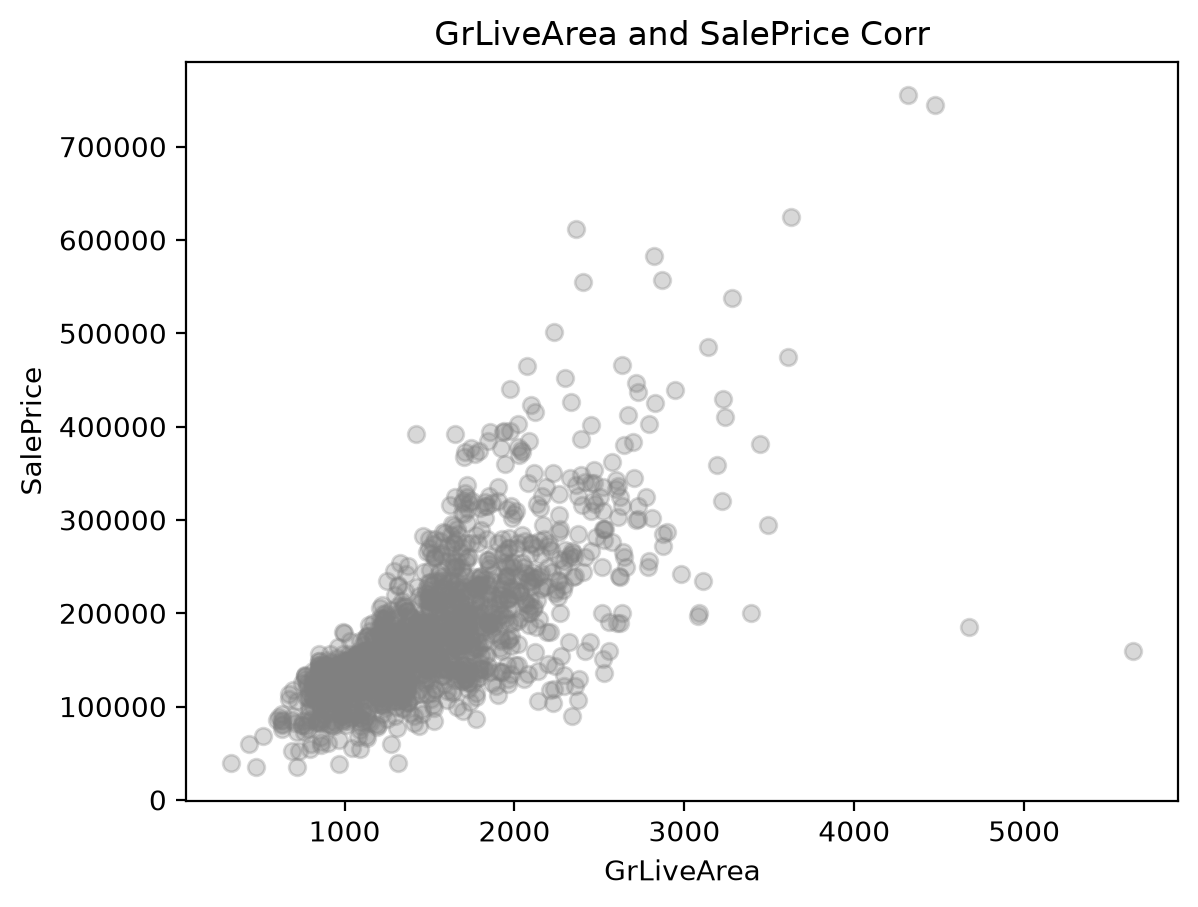

In [2]:
# 여기에 코드를 작성하세요.

df_area = df['GrLivArea'].dropna()
df_price = df['SalePrice'].dropna()

# 1. 피어슨 상관분석
r, p_value = stats.pearsonr(df_area, df_price)

print('\n[Pearson 상관분석]')
print(f'상관계수 r : {r:.3f}')
print(f'p-value : {p_value:.3f} | 판단 : 유의하다.' if p_value <= 0.5 else '판단 : 유의하지않다.')
# 2. 결정계수 r²
r_squared = r ** 2

print(f'r² : {r_squared:.3f}')


# 3. 산점도
plt.scatter(df_area, df_price, alpha=0.3, color='gray')

plt.xlabel('GrLiveArea')
plt.ylabel('SalePrice')
plt.title('GrLiveArea and SalePrice Corr')
plt.show()

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
    - r값이 양수값이고 절댓값이 0.71이므로 비교적 강한 양의 상관관계

- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
    - p-value가 0.05보다 작으므로 상관계수가 0일 것이라는 귀무가설을 기각한다.
    - 즉, 두 변수는 통계적으로 유의하다.

- $r^2$은 이 관계에서 무엇을 의미하나요?
    - 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소제곱 단순 선형회귀를 적합하여
    - 결정계수 r^2이 약 0.50이다.
    - 즉, 생활면적을 이용한 직선 모형이 이 자료의 가격 변동을 약 50.2% 설명한다.

- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
    - 아니오.
    - 이미 존재하는 주택의 특성을 관찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인하지 못했다.

---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?


[표본 데이터]


,GrLivArea,SalePrice
892,1068,154500
1105,2622,325000
413,1028,115000
522,1664,159000
1036,1620,315500



[이상치 추가 전 Pearson 상관분석]
상관계수 r : 0.706
p-value : 0.000

[이상치 추가 후 Pearson 상관분석]
상관계수 r : 0.260
p-value : 0.065


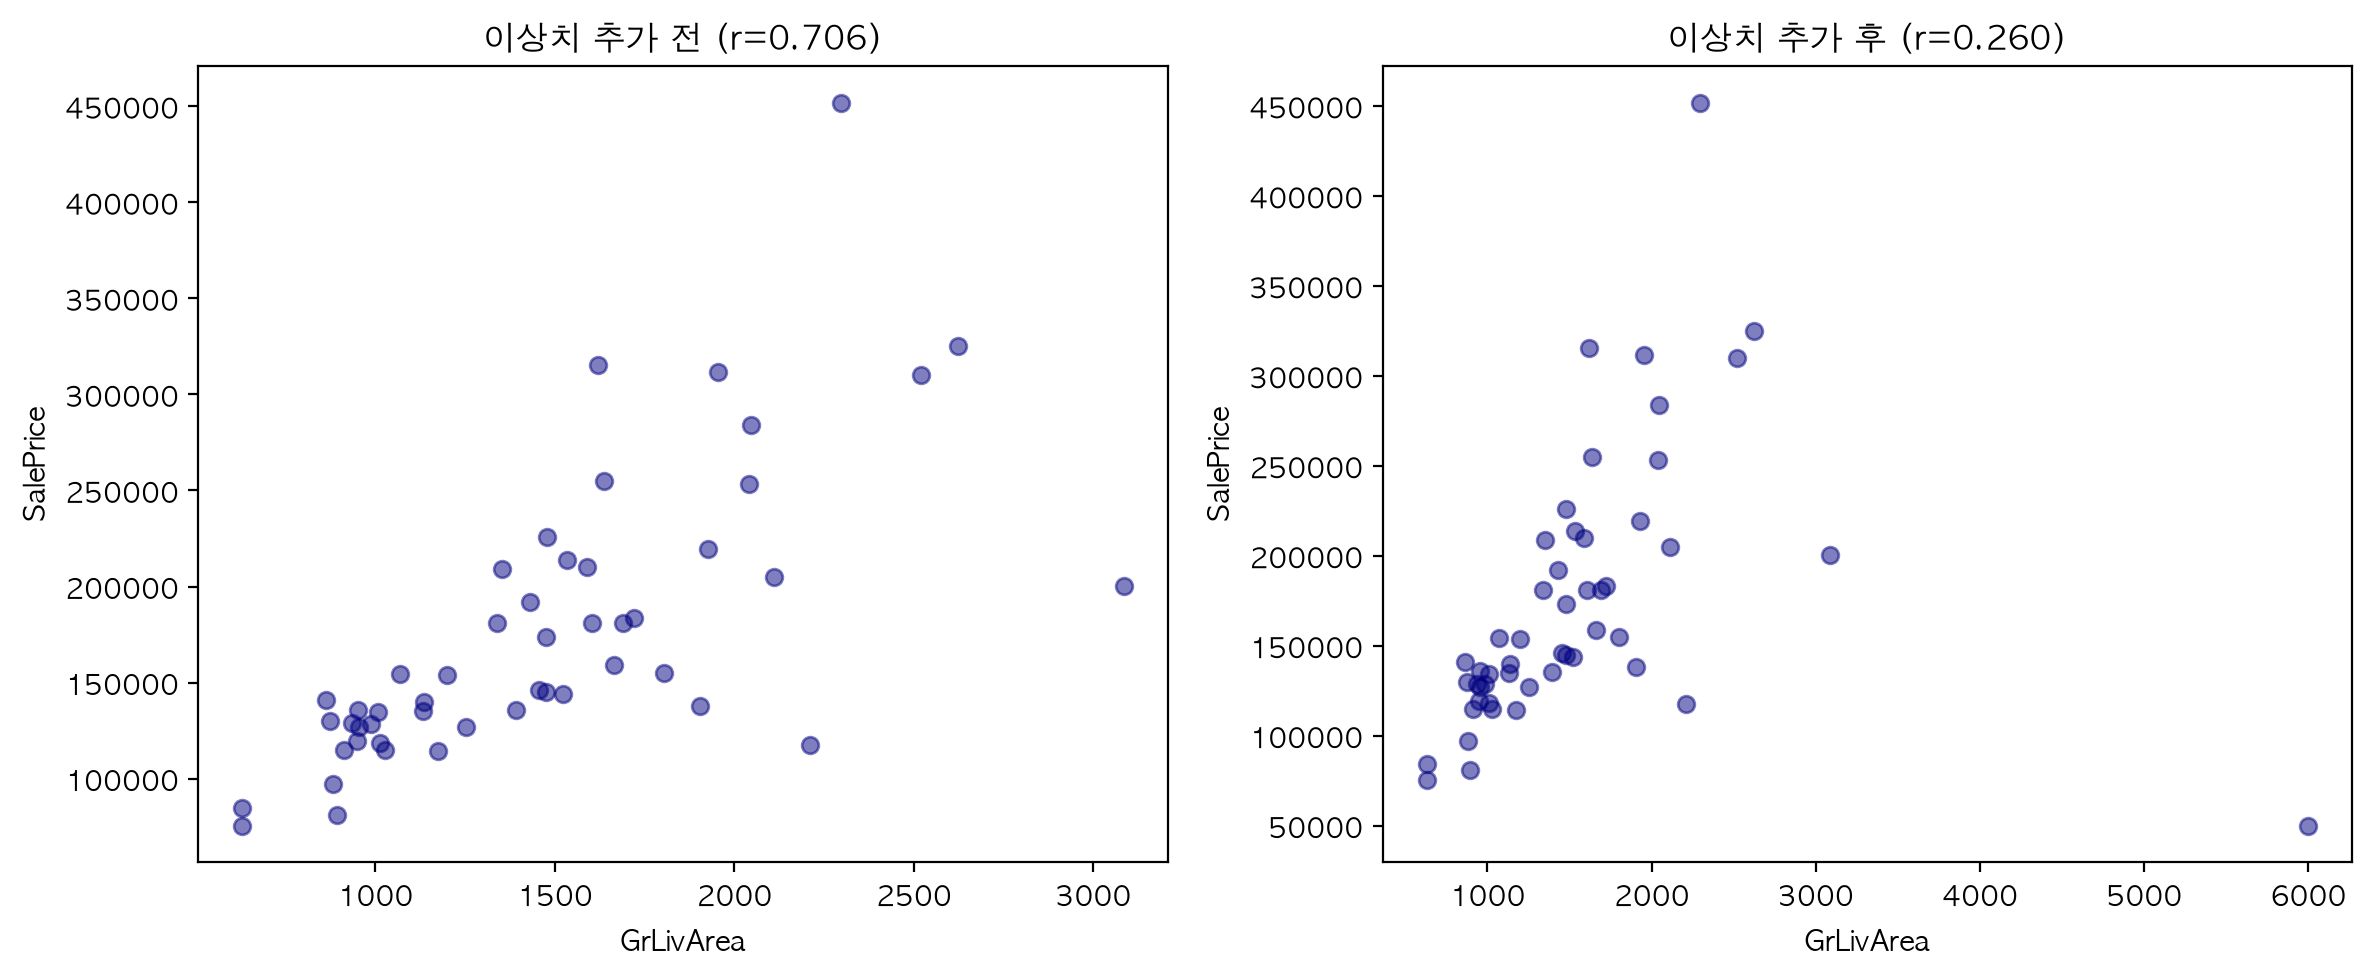


[결과 비교]
이상치 추가 전 r : 0.706
이상치 추가 후 r : 0.260
r 변화량 : -0.446


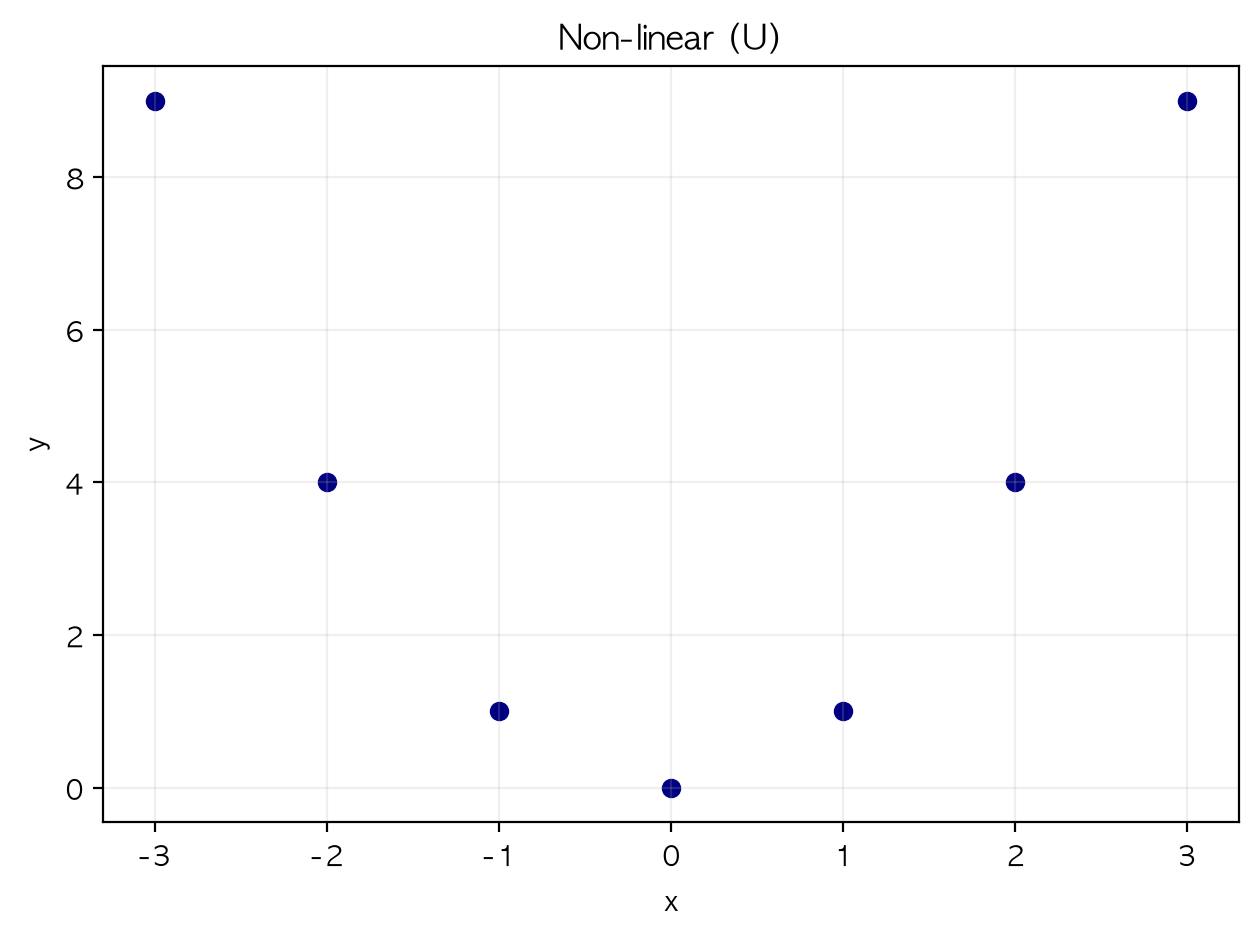

In [3]:
# 여기에 코드를 작성하세요.

# 한글 폰트 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'NanumGothic'  # Linux

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# A
# 1. GrLivArea, SalePrice에서 50행 표본 추출
sample_df = df[['GrLivArea', 'SalePrice']].sample(n=50, random_state=42)

print('[표본 데이터]')
display(sample_df.head())


# 2. 이상치 추가 전 Pearson 상관분석
r_before, p_before = stats.pearsonr(sample_df['GrLivArea'], sample_df['SalePrice'])

print('\n[이상치 추가 전 Pearson 상관분석]')
print(f'상관계수 r : {r_before:.3f}')
print(f'p-value : {p_before:.3f}')


# 3. 가상 이상치를 표본에만 추가
outlier = pd.DataFrame({'GrLivArea': [6000],'SalePrice': [50000]})

sample_outlier_df = pd.concat([sample_df, outlier])


# 4. 이상치 추가 후 Pearson 상관분석
r_after, p_after = stats.pearsonr(sample_outlier_df['GrLivArea'],sample_outlier_df['SalePrice'])

print('\n[이상치 추가 후 Pearson 상관분석]')
print(f'상관계수 r : {r_after:.3f}')
print(f'p-value : {p_after:.3f}')


# 5. 추가 전후 산점도 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 이상치 추가 전
axes[0].scatter(sample_df['GrLivArea'],sample_df['SalePrice'], alpha=0.5, color='navy')

axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title(f'이상치 추가 전 (r={r_before:.3f})')


# 이상치 추가 후
axes[1].scatter(sample_outlier_df['GrLivArea'],sample_outlier_df['SalePrice'], alpha=0.5, color='navy')

axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')
axes[1].set_title(f'이상치 추가 후 (r={r_after:.3f})')

plt.tight_layout()
plt.show()

# 결과 비교
print('\n[결과 비교]')
print(f'이상치 추가 전 r : {r_before:.3f}')
print(f'이상치 추가 후 r : {r_after:.3f}')
print(f'r 변화량 : {r_after - r_before:.3f}')


# B
## 비선형 관계

x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2 

plt.scatter(x, y, color='navy')

plt.title('Non-linear (U)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
    - r 0.71-> 0.26으로 감소, p-value는 0.05 미만에서 0.06으로 증가했다.
    - 귀무가설을 기각함에서 귀무가설을 기각할 수 없음으로 판단이 변경 

- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
    - 요약값만 보면 변화의 원인을 한 눈에 파악하기 어려움
    - 산점도는 멀리 떨어진 점들과 일부 선형관계를 한 눈에 파악하기 쉬움
    - 이 점은 이상치도 한 눈에 파악하기 쉽다는 것을 알려줌

- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
    - 피어슨 r은 직선형태의 관계를 요약함
    - U자형 그래프의 왼쪽과 오른쪽은 서로 반대방향의 선형 움직임을 보이기 때문에 0에 가까움

- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
    - 아니오. r=0은 선형관계가 거의 없다는 뜻, 비선령 관계는 존재할 수 있다.

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.


[표본 데이터]


,LotArea,SalePrice
0,8450,208500
1,9600,181500
2,11250,223500
3,9550,140000
4,14260,250000



[Pearson 상관분석]
상관계수 r : 0.264
p-value : 0.000
r² : 0.070


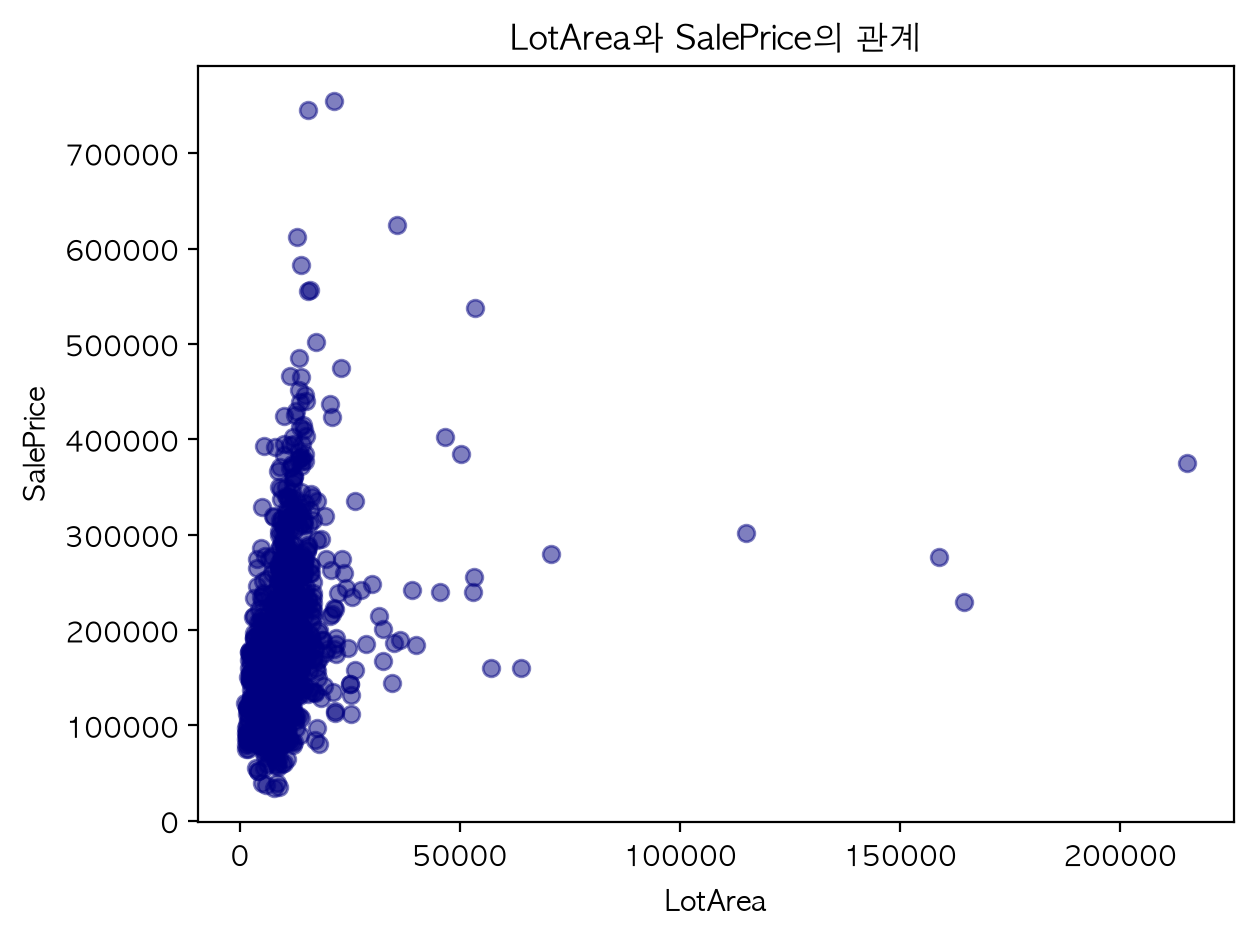


[통계적 유의성]
p-value가 0.05보다 작으므로 통계적으로 유의한 상관관계가 있습니다.


In [4]:
# 여기에 코드를 작성하세요.

sample_df = df[['LotArea', 'SalePrice']]

print('[표본 데이터]')
display(sample_df.head())

# 1. 피어슨 상관계수
r, p_value = stats.pearsonr(sample_df['LotArea'], sample_df['SalePrice'])

r_squared = r ** 2

print('\n[Pearson 상관분석]')
print(f'상관계수 r : {r:.3f}')
print(f'p-value : {p_value:.3f}')
print(f'r² : {r_squared:.3f}')

# 2. 산점도
plt.scatter(sample_df['LotArea'], sample_df['SalePrice'], alpha=0.5, color='navy')

plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.title('LotArea와 SalePrice의 관계')

plt.tight_layout()
plt.show()


# 4. 통계적 유의성 판단
print('\n[통계적 유의성]')

if p_value < 0.05:
    print('p-value가 0.05보다 작으므로 통계적으로 유의한 상관관계가 있습니다.')
else:
    print('p-value가 0.05 이상이므로 통계적으로 유의한 상관관계가 있다고 보기 어렵습니다.')

### 질문

- 관계의 방향과 강도는 어떠한가요?

    - 피어슨 상관계수가 0.264이므로 양의 방향으로 상관성이 존재하며, 강도는 약한 상관성을 이룬다.

<br>

- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?

    - 아니요. p-value가 유의수준보다 작다는 것은 두 변수의 상관관계가 0이 아니라고 볼 통계적 근거가 있다는 것이다.

    - 강한 관계는 상관관계를 통해서 해석한다.

<br>

- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?

    - 아니요. 상관분석만으로 인과관계를 파악할 수 없다.

    - 양의 상관관계가 나타났지만, 이것이 직접적으로 대지면적이 넓어지면 매매가격이 오른다는 것을 의미하지 않는다.
    - 다른 변수와의 관계도 파악해야한다.

<br>

- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.

    - Neighborhood(인근 지역), YearBuilt(최초 건축연도) 등의 혼란변수에 따라 두 변수에 영향을 줄 수 있다.

<br>

- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

    - 피어슨 상관계수는 선형관계를 바탕으로 나타내기 때문에 상관계수가 0에 가깝다고 해서 두 변수 사이에 아무 관계는 없다고 할 수는 없다.
    
    - U자형 관계는 한쪽은 음의 방향, 다른쪽은 양의 방향의 관계가 나타나기 때문에 두 방향이 다르게 나타남에 따라 상관계수는 0에 가깝다고 나타날 수 있다.


---

## 실습 마무리

- 어떤 문제가 있었는가?
    - 상관계수와 p-value만으로는 관계를 명확하게 규정하기 어려움

- 어떻게 개선했는가?
    - r, r^2, p-value, 산점도, 이상치 유/무

- 무엇을 근거로 개선되었다고 판단했는가?
    - 이상치 값 하나로 r값과 p-value가 달라지는 것을 확인했다.
    - 본 데이터의 이상치를 제거한다면 정상적인 r값과 p-value로 올바른 통계적 해석이 가능하다.
    
피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.
